特点：
- 直接调用 `myexp.main.main`
- 首次运行后把仿真结果缓存到本地，后面只改图不用重跑
- 包含总体 `bid_p / bid_r`、日前与日内修正对比、资源贡献、车辆群体热力图
- 支持切换不同车辆，查看单车修正后 `bid_p / bid_r` 柱状图与荷电状态曲线
- 新增了市场价格日期与研究日 RegD 信号图，可以直接确认当天使用的价格和调频信号


In [1]:
try:
    from IPython import get_ipython
    _ip = get_ipython()
    if _ip is not None:
        _ip.run_line_magic('matplotlib', 'inline')
except Exception:
    pass

from pathlib import Path
import sys

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from IPython.display import Markdown, display

try:
    import ipywidgets as widgets
except ImportError:
    widgets = None

candidate_roots = [Path.cwd(), *Path.cwd().parents]
PROJECT_ROOT = None
for candidate in candidate_roots:
    if (candidate / "myexp").exists():
        PROJECT_ROOT = candidate
        break

if PROJECT_ROOT is None:
    raise RuntimeError("未找到包含 'myexp' 的项目根目录。")

if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from myexp.notebook_viz_utils import (
    build_analysis_bundle,
    build_selected_ev_actual_df,
    build_selected_ev_soc_compare_df,
    build_selected_ev_slot_df,
    load_or_run_simulation,
)

sns.set_theme(style="whitegrid", context="talk")
plt.rcParams["font.sans-serif"] = ["SimHei", "Microsoft YaHei", "DejaVu Sans"]
plt.rcParams["axes.unicode_minus"] = False
FIGSIZE_MAIN = (8, 4)
FIGSIZE_HEATMAP = (10.5, 7.2)
FIGSIZE_EV = (8.2, 4.7)

FORCE_RERUN = False
DATA_SOURCE = "data_process"
DAY_PRICE = 15
MAT_FILE = None
SAVE_RESULTS_FILES = False
CACHE_SUFFIX = f"{DATA_SOURCE}_day{DAY_PRICE}" if DATA_SOURCE == "data_process" else (Path(MAT_FILE).stem if MAT_FILE else DATA_SOURCE)
CACHE_PATH = PROJECT_ROOT / "results" / "notebook_cache" / f"myexp_{CACHE_SUFFIX}_simulation.pkl"

print(f"PROJECT_ROOT = {PROJECT_ROOT}")
print(f"CACHE_PATH = {CACHE_PATH}")
if DATA_SOURCE == "data_process":
    print(f"DAY_PRICE = {DAY_PRICE}")
widget_status = "可用" if widgets is not None else "不可用"
print(f"交互控件状态 = {widget_status}")


PROJECT_ROOT = e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main
CACHE_PATH = e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\results\notebook_cache\myexp_data_process_day15_simulation.pkl
DAY_PRICE = 15
交互控件状态 = 不可用


In [2]:
sim = load_or_run_simulation(
    project_root=PROJECT_ROOT,
    cache_path=CACHE_PATH,
    force_rerun=FORCE_RERUN,
    data_source=DATA_SOURCE,
    mat_file=MAT_FILE,
    save_results=SAVE_RESULTS_FILES,
    day_price=DAY_PRICE,
)
bundle = build_analysis_bundle(sim)
slot_df = bundle["slot_df"]
resource_df = bundle["resource_df"]
heatmaps = bundle["ev_heatmaps"]
summary_df = bundle["summary_df"]
resource_meta = sim["resource_meta"]

display(Markdown("### 仿真摘要"))
display(summary_df)
display(Markdown(f"缓存文件：{CACHE_PATH}"))
display(Markdown(f"车辆数量：{len(resource_meta['ev_labels'])}，分钟级控制点：{sim['result']['P_dis_actual'].shape[1]}"))


### 仿真摘要

,指标,数值
0,时段数,24.000000
1,资源总数,122.000000
2,EV数量,120.000000
3,日前利润(USD),2733.791778
4,实际利润(USD),2958.137045
5,日前电池退化费用(USD),1063.233857
6,实际电池退化费用(USD),928.238787
7,利润增量(USD),224.345267
8,利润增量(%),8.206377
9,bid_p平均修正(MW),0.046853


缓存文件：e:\研究活\Real-time-operation-strategy-of-virtual-power-plants-main\results\notebook_cache\myexp_data_process_day15_simulation.pkl

车辆数量：120，分钟级控制点：1440

### 市场日期与研究日调频信号

  调频价格 shape: (24, 2)
  容量价格范围: [7.17, 99.12] $/MW
  里程价格范围: [0.00, 3.02] $/MW
  能量价格 shape: (24,)
  能量价格范围: [45.38, 101.22] $/MWh


- 市场价格日期：`2022-07-15`
- RegD实际信号日期：`2020-07-16`
- RegD信号来源：`07 2020.xlsx / day 16`

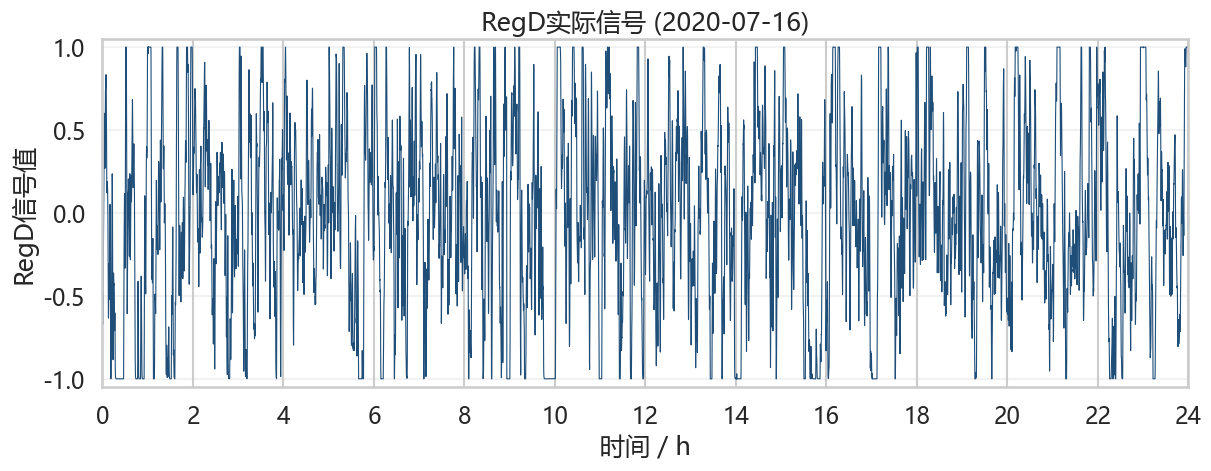

In [3]:
display(Markdown('### ' + '市场日期与研究日调频信号'))

from myexp.market_price_plot_utils import load_day_market_prices

signal_day = np.asarray(sim['Signal_day'], dtype=float)
points_per_hour = max(len(signal_day) // 24, 1)
x_hours = np.arange(len(signal_day), dtype=float) / points_per_hour

market_date_label = '未知'
regd_date_label = '未知'
regd_source_label = '来自仿真输入'

if DATA_SOURCE == 'data_process':
    price_series = load_day_market_prices(day_price=DAY_PRICE, base_dir=PROJECT_ROOT)
    market_date_label = price_series.market_date
    regd_day = DAY_PRICE + 1
    regd_date_label = f'2020-07-{regd_day:02d}'
    regd_source_label = f'07 2020.xlsx / day {regd_day}'
else:
    market_date_label = 'MAT ' + (Path(MAT_FILE).name if MAT_FILE else 'param.mat')
    regd_date_label = 'MAT ' + (Path(MAT_FILE).name if MAT_FILE else 'Signal_day')
    regd_source_label = '来自 data_prepare 中的 Signal_day'

display(Markdown(
    f'- 市场价格日期：`{market_date_label}`\n'
    f'- RegD实际信号日期：`{regd_date_label}`\n'
    f'- RegD信号来源：`{regd_source_label}`'
))

fig, ax = plt.subplots(figsize=(12, 4.6), constrained_layout=True)
ax.plot(x_hours, signal_day, color='#1f4e79', linewidth=0.8)
for hour in range(0, 25, 2):
    ax.axvline(hour, color='#d9dde3', linewidth=0.6, linestyle='--', zorder=0)
ax.set_xlim(0, 24)
ax.set_ylim(-1.05, 1.05)
ax.set_xticks(range(0, 25, 2))
ax.set_xlabel('时间 / h')
ax.set_ylabel('RegD信号值')
ax.set_title(f'RegD实际信号 ({regd_date_label})')
ax.grid(True, axis='y', alpha=0.25)
plt.show()


### 修正后基础功率投标

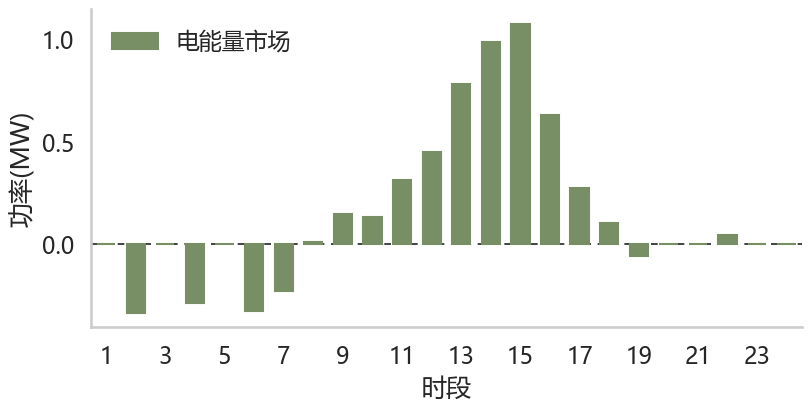

### 修正后调频容量投标

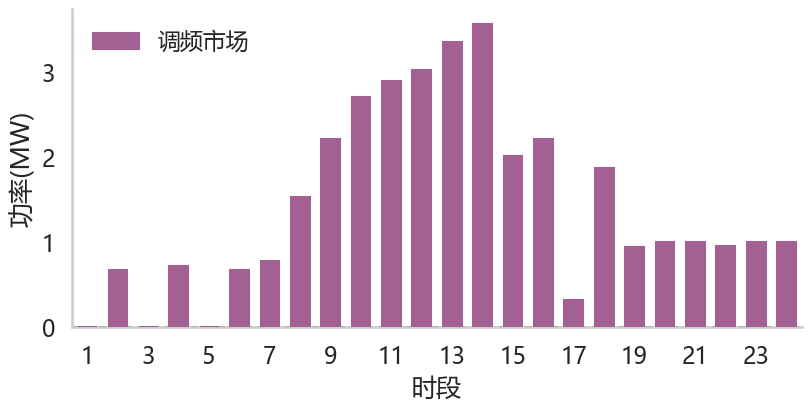

In [4]:
display(Markdown("### 修正后基础功率投标"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.bar(
    slot_df["slot"],
    slot_df["bid_p_rev"],
    width=0.62,
    color="#788F66",
    edgecolor="#788F66",
    label="电能量市场",
    zorder=3,
)
ax.axhline(0, color="#222222", linewidth=1.2, linestyle=(0, (4, 4)), zorder=2)
ax.set_xlim(0.5, float(slot_df["slot"].max()) + 0.5)
ax.set_xticks(range(1, int(slot_df["slot"].max()) + 1, 2))
ax.set_xlabel("时段")
ax.set_ylabel("功率(MW)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False, loc="upper left")
plt.show()

display(Markdown("### 修正后调频容量投标"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.bar(
    slot_df["slot"],
    slot_df["bid_r_rev"],
    width=0.62,
    color="#A36193",
    edgecolor="#A36193",
    label="调频市场",
    zorder=3,
)
ax.axhline(0, color="#222222", linewidth=1.2, linestyle=(0, (4, 4)), zorder=2)
ax.set_xlim(0.5, float(slot_df["slot"].max()) + 0.5)
ax.set_xticks(range(1, int(slot_df["slot"].max()) + 1, 2))
ax.set_xlabel("时段")
ax.set_ylabel("功率(MW)")
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.grid(False)
ax.legend(frameon=False, loc="upper left")
plt.show()


### 基础功率资源贡献

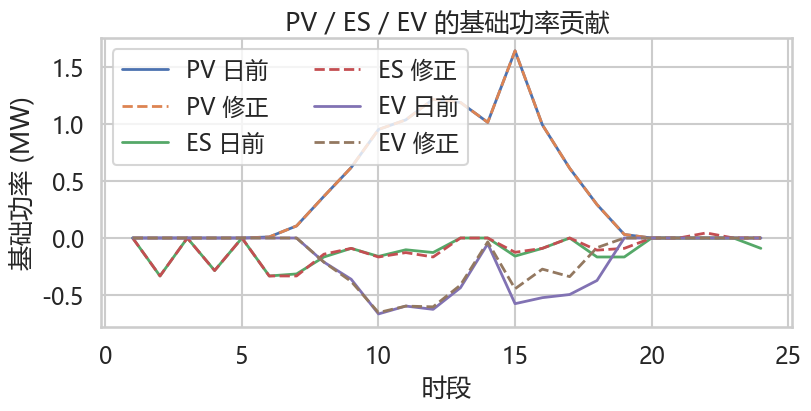

### 调频功率资源贡献

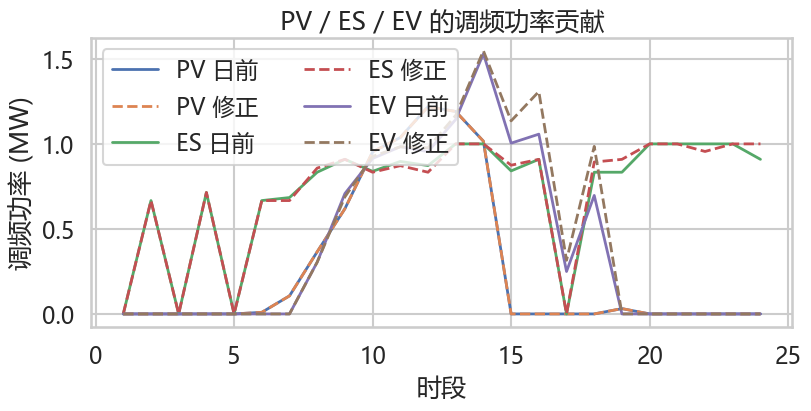

### 市场价格曲线

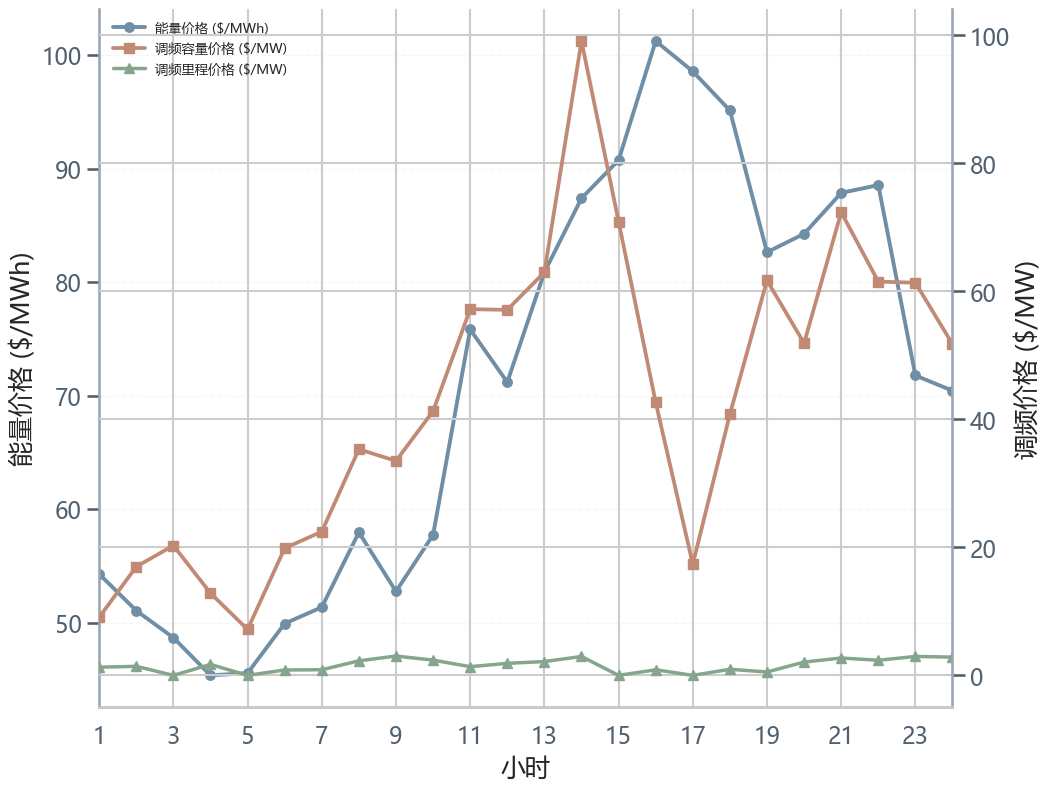

### 利润对比与滚动修正频次

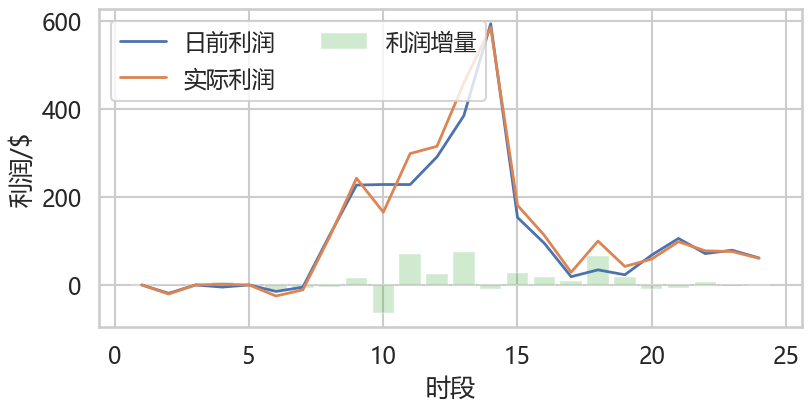

In [5]:
base_day = resource_df.pivot(index="slot", columns="resource_type", values="bid_p_day")
base_rev = resource_df.pivot(index="slot", columns="resource_type", values="bid_p_rev")
reg_day = resource_df.pivot(index="slot", columns="resource_type", values="bid_r_day")
reg_rev = resource_df.pivot(index="slot", columns="resource_type", values="bid_r_rev")

display(Markdown("### 基础功率资源贡献"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
for resource_name in ["PV", "ES", "EV"]:
    ax.plot(base_day.index, base_day[resource_name], linewidth=2.0, label=f"{resource_name} 日前")
    ax.plot(base_rev.index, base_rev[resource_name], linewidth=2.0, linestyle="--", label=f"{resource_name} 修正")
ax.set_xlabel("时段")
ax.set_ylabel("基础功率 (MW)")
ax.set_title("PV / ES / EV 的基础功率贡献")
ax.legend(ncol=2)
plt.show()

display(Markdown("### 调频功率资源贡献"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
for resource_name in ["PV", "ES", "EV"]:
    ax.plot(reg_day.index, reg_day[resource_name], linewidth=2.0, label=f"{resource_name} 日前")
    ax.plot(reg_rev.index, reg_rev[resource_name], linewidth=2.0, linestyle="--", label=f"{resource_name} 修正")
ax.set_xlabel("时段")
ax.set_ylabel("调频功率 (MW)")
ax.set_title("PV / ES / EV 的调频功率贡献")
ax.legend(ncol=2)
plt.show()

display(Markdown("### 市场价格曲线"))
price_x = slot_df["slot"].to_numpy(dtype=float)

fig, ax_left = plt.subplots(figsize=(10.4, 7.8), constrained_layout=True)
fig.patch.set_facecolor("white")
ax_left.set_facecolor("white")

line_energy = ax_left.plot(
    price_x,
    slot_df["price_e"],
    color="#6F8FA6",
    marker="o",
    linewidth=2.8,
    markersize=6.8,
    label="能量价格 ($/MWh)",
)[0]

ax_left.set_xlabel("小时")
ax_left.set_ylabel("能量价格 ($/MWh)")
ax_left.set_xticks(range(1, 25, 2))
ax_left.set_xlim(1, 24)
ax_left.grid(True, axis="y", linestyle="--", alpha=0.18, linewidth=1.0)
ax_left.spines["top"].set_visible(False)
ax_left.spines["right"].set_visible(False)
ax_left.spines["left"].set_color("#9AA6B2")
ax_left.spines["bottom"].set_color("#9AA6B2")
ax_left.tick_params(colors="#506070")

ax_right = ax_left.twinx()
line_capacity = ax_right.plot(
    price_x,
    slot_df["price_reg_cap"],
    color="#C08A74",
    marker="s",
    linewidth=2.7,
    markersize=6.6,
    label="调频容量价格 ($/MW)",
)[0]
line_mileage = ax_right.plot(
    price_x,
    slot_df["price_reg_mileage"],
    color="#86A58D",
    marker="^",
    linewidth=2.5,
    markersize=6.6,
    label="调频里程价格 ($/MW)",
)[0]

ax_right.set_ylabel("调频价格 ($/MW)")
ax_right.spines["top"].set_visible(False)
ax_right.spines["left"].set_visible(False)
ax_right.spines["right"].set_color("#9AA6B2")
ax_right.tick_params(colors="#506070")

handles = [line_energy, line_capacity, line_mileage]
labels = [handle.get_label() for handle in handles]
legend = ax_left.legend(
    handles,
    labels,
    loc="upper left",
    bbox_to_anchor=(0.01, 0.99),
    frameon=False,
    fontsize=9.5,
    handlelength=2.4,
    labelspacing=0.55,
    borderaxespad=0.0,
)
legend.get_frame().set_linewidth(0.0)
legend.get_frame().set_facecolor("none")
plt.show()

display(Markdown("### 利润对比与滚动修正频次"))
fig, ax = plt.subplots(figsize=FIGSIZE_MAIN, constrained_layout=True)
ax.plot(slot_df["slot"], slot_df["profit_day"], linewidth=2.0, label="日前利润")
ax.plot(slot_df["slot"], slot_df["profit_actual"], linewidth=2.0, label="实际利润")
ax.bar(slot_df["slot"], slot_df["profit_delta"], alpha=0.22, color="tab:green", label="利润增量")
# ax.plot(slot_df["slot"], slot_df["revision_count"], linewidth=1.6, color="black", linestyle=":", label="滚动修正次数")
ax.set_xlabel("时段")
ax.set_ylabel("利润/$")
# ax.set_title("利润对比与滚动修正频次")
ax.legend(ncol=2)
plt.show()


未检测到交互控件，修改下方默认车辆编号后重跑本单元即可切换车辆。


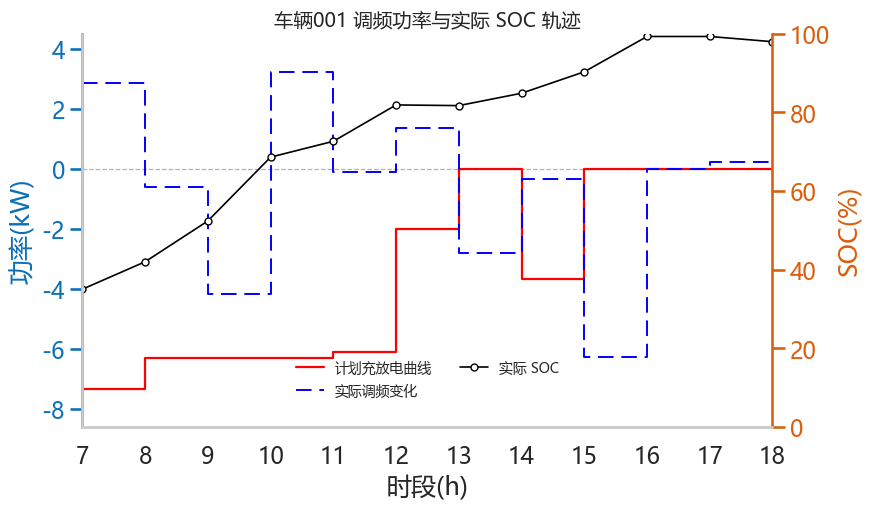

In [6]:
def plot_selected_ev(ev_number=1):
    slot_ev_df = build_selected_ev_slot_df(sim, int(ev_number))
    actual_ev_df = build_selected_ev_actual_df(sim, int(ev_number))
    compare_df = build_selected_ev_soc_compare_df(sim, int(ev_number))
    ev_label = slot_ev_df["ev_label"].iat[0]
    vehicle_label = str(ev_label).replace("EV_", "车辆")

    available_slot_df = slot_ev_df.loc[slot_ev_df["available"]].copy()
    available_compare_df = compare_df.loc[compare_df["available"]].copy()
    available_actual_df = actual_ev_df.loc[actual_ev_df["available"]].copy()
    if available_slot_df.empty or available_compare_df.empty:
        print(f"{vehicle_label} 当前无可视化时段。")
        return

    slot_summary_df = available_compare_df.groupby("slot", as_index=False).agg(
        reg_mean_kw=("reg_power_kw", lambda s: float(np.mean(s.to_numpy(dtype=float)))),
        soc_actual_end_pct=("soc_actual_pct", lambda s: float(s.iloc[-1])),
    )
    slot_view_df = available_slot_df[["slot", "hour", "bid_p_rev"]].merge(slot_summary_df, on="slot", how="left")

    x_slot = slot_view_df["hour"].to_numpy(dtype=float)
    step_x = np.r_[x_slot, x_slot[-1] + 1.0]
    plan_power_kw = slot_view_df["bid_p_rev"].to_numpy(dtype=float) * 1000.0
    reg_mean_kw = slot_view_df["reg_mean_kw"].fillna(0.0).to_numpy(dtype=float)

    initial_soc_pct = float(available_actual_df["soc_start_pct"].iloc[0])
    x_soc = np.r_[x_slot[0], x_slot + 1.0]
    soc_actual_path = np.r_[initial_soc_pct, slot_view_df["soc_actual_end_pct"].fillna(initial_soc_pct).to_numpy(dtype=float)]

    power_min = min(float(np.nanmin(plan_power_kw)), 0.0)
    power_max = max(
        float(np.nanmax(plan_power_kw)),
        float(np.nanmax(reg_mean_kw)),
        0.0,
    )
    power_min = min(power_min, float(np.nanmin(reg_mean_kw)), 0.0)
    power_margin = max((power_max - power_min) * 0.12, 1.0)

    fig, ax1 = plt.subplots(figsize=(8.6, 5.0), constrained_layout=True)
    ax1.axhline(0.0, color="0.70", linewidth=0.9, linestyle="--")
    line_plan = ax1.step(
        step_x,
        np.r_[plan_power_kw, plan_power_kw[-1]],
        where="post",
        color="red",
        linewidth=1.6,
        label="计划充放电曲线",
    )[0]
    line_reg = ax1.step(
        step_x,
        np.r_[reg_mean_kw, reg_mean_kw[-1]],
        where="post",
        color="blue",
        linewidth=1.4,
        linestyle=(0, (8, 4)),
        label="实际调频变化",
    )[0]
    ax1.set_ylabel("功率(kW)", color="#0B70B8")
    ax1.tick_params(axis="y", colors="#0B70B8")
    ax1.spines["left"].set_color("#0B70B8")
    ax1.spines["top"].set_visible(False)
    ax1.spines["right"].set_visible(False)
    ax1.set_ylim(power_min - power_margin, power_max + power_margin)

    ax2 = ax1.twinx()
    line_soc_actual = ax2.plot(
        x_soc,
        soc_actual_path,
        color="black",
        linewidth=1.2,
        marker="o",
        markersize=5,
        markerfacecolor="white",
        label="实际 SOC",
    )[0]
    ax2.set_ylabel("SOC(%)", color="#D95F0E")
    ax2.tick_params(axis="y", colors="#D95F0E")
    ax2.spines["right"].set_color("#D95F0E")
    ax2.spines["top"].set_visible(False)
    ax2.set_ylim(0.0, 100.0)

    xticks = np.arange(int(x_slot[0]), int(x_slot[-1]) + 2, 1)
    ax1.set_xlim(x_slot[0], x_slot[-1] + 1.0)
    ax1.set_xticks(xticks)
    ax1.set_xlabel("时段(h)")
    ax1.grid(False)
    ax2.grid(False)

    handles = [line_plan, line_reg, line_soc_actual]
    labels = ["计划充放电曲线", "实际调频变化", "实际 SOC"]
    ax1.legend(handles, labels, loc="lower center", bbox_to_anchor=(0.5, 0.04), frameon=False, fontsize=10, ncol=2)
    ax1.set_title(f"{vehicle_label} 调频功率与实际 SOC 轨迹", fontsize=14)
    plt.show()


ev_count = len(resource_meta["ev_labels"])
if ev_count == 0:
    print("当前结果中没有车辆数据。")
elif widgets is None:
    DEFAULT_VEHICLE = 1
    print("未检测到交互控件，修改下方默认车辆编号后重跑本单元即可切换车辆。")
    plot_selected_ev(DEFAULT_VEHICLE)
else:
    display(Markdown("### 选择单辆车查看详细轨迹"))
    widgets.interact(
        plot_selected_ev,
        ev_number=widgets.IntSlider(value=1, min=1, max=ev_count, step=1, description="车辆编号"),
    )


当前批量查看车辆: [1, 5, 10, 20]


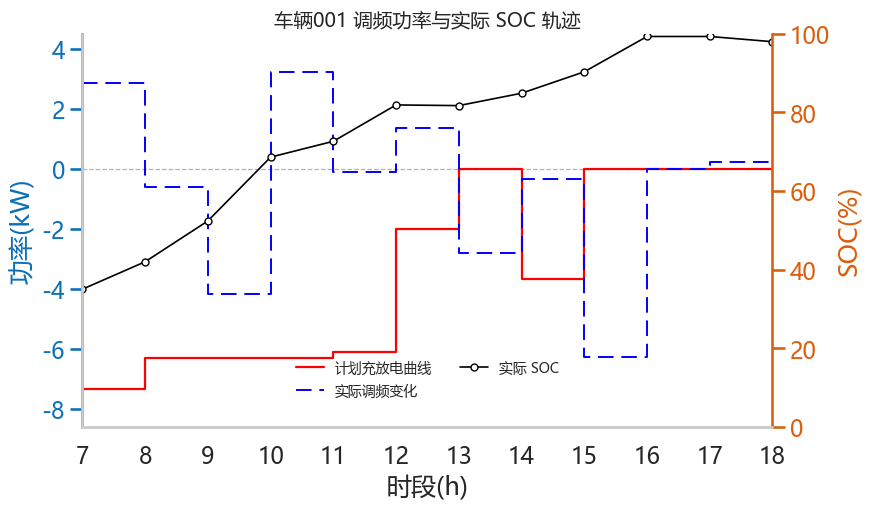

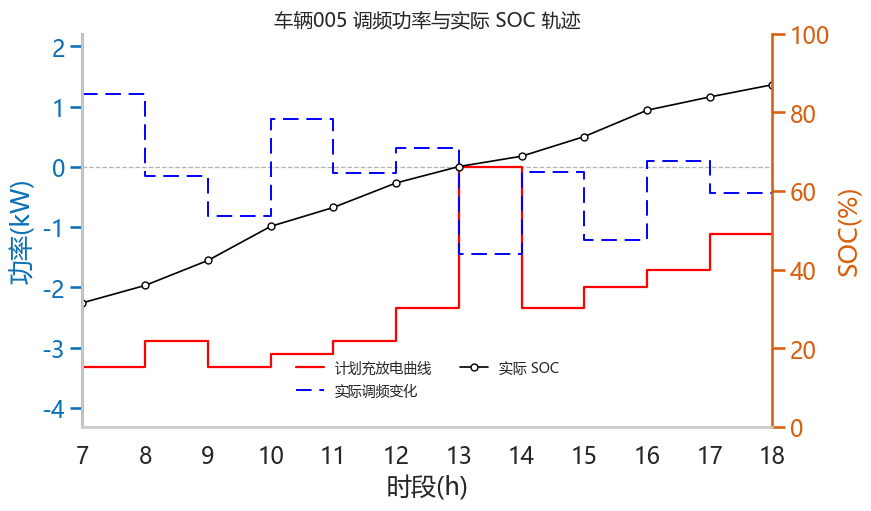

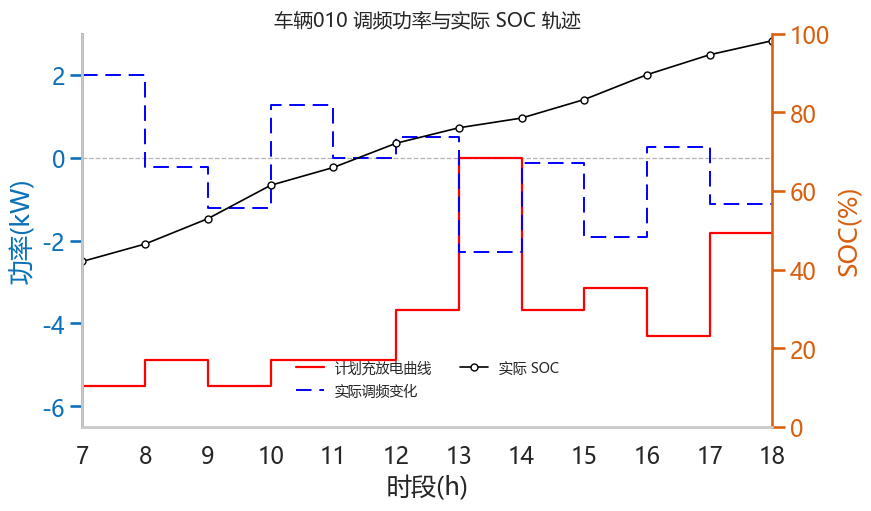

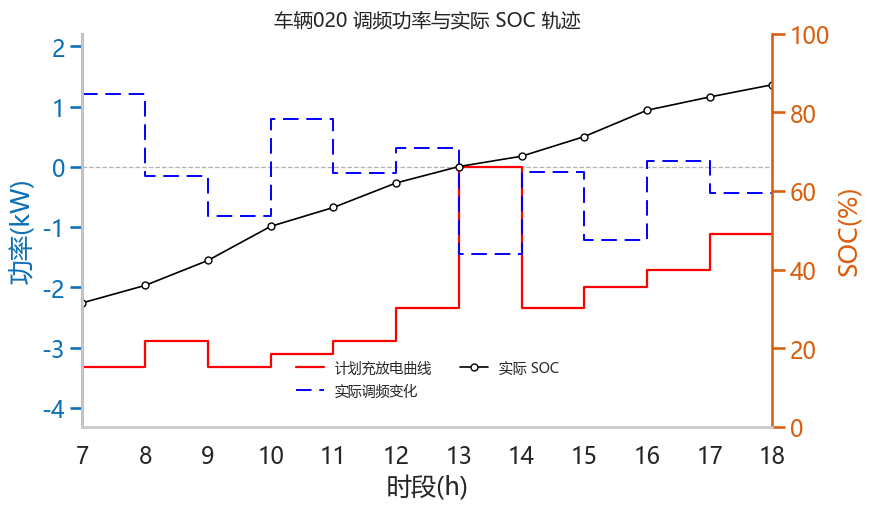

In [7]:
DEFAULT_MULTI_VEHICLES = [1, 5, 10, 20]
selected_vehicles = []
for ev_number in DEFAULT_MULTI_VEHICLES:
    ev_int = int(ev_number)
    if 1 <= ev_int <= ev_count and ev_int not in selected_vehicles:
        selected_vehicles.append(ev_int)

if ev_count == 0:
    print("当前结果中没有车辆数据。")
elif not selected_vehicles:
    print("默认车辆编号超出范围，请修改 DEFAULT_MULTI_VEHICLES 后重跑本单元。")
else:
    print(f"当前批量查看车辆: {selected_vehicles}")
    for ev_number in selected_vehicles:
        plot_selected_ev(ev_number)


## 使用说明

- 只想改图，不想重跑时，保持 `FORCE_RERUN = False`
- 想拿最新代码重新算一遍时，把 `FORCE_RERUN = True`
- 当前默认使用 `data_process` 的第 `15` 号价格数据；修改 `DAY_PRICE` 就能切换市场价格日期
- 在 `data_process` 模式下，仿真会使用 `day_reg = DAY_PRICE + 1` 的 RegD 信号；摘要下方的“市场日期与研究日调频信号”单元会直接显示对应日期
- 想切换到 `data_prepare` 的 `.mat` 数据，可以把 `DATA_SOURCE` 改成 `"data_prepare"`，并设置 `MAT_FILE`
- 单车图下方新增了批量浏览单元，修改 `DEFAULT_MULTI_VEHICLES` 就能一次看多辆车
- 如果想继续加图，优先复用 `slot_df`、`resource_df`、`heatmaps`、`build_selected_ev_*` 以及 `sim["Signal_day"]` 这些对象
